In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import sys
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
sys.path.append('../../src')
from data_loader import DataLoader
from configs.configs import SetupEnum, SamplingEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm


%matplotlib inline
np.random.seed(777)

# Load data sequence 09 (0033)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


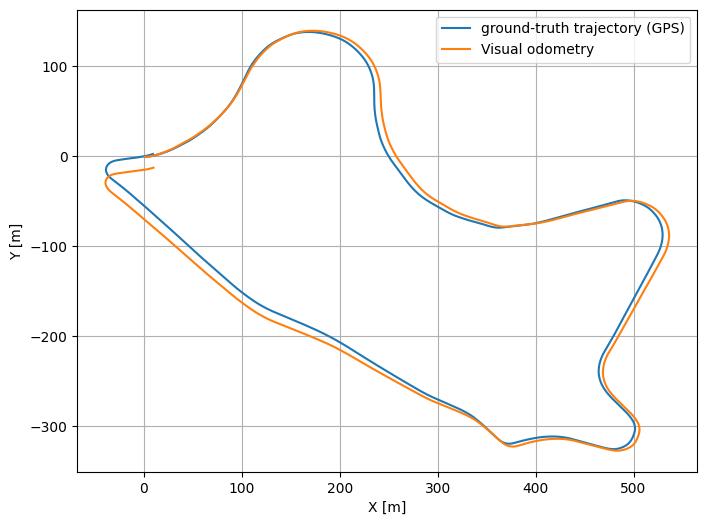

In [2]:
kitti_root_dir = '../../data'
vo_root_dir = '../../vo_estimates'
noise_vector_dir = '../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0,
                  visualize_data=True
                 )

## Display data with noise

### VO trajectory with noise

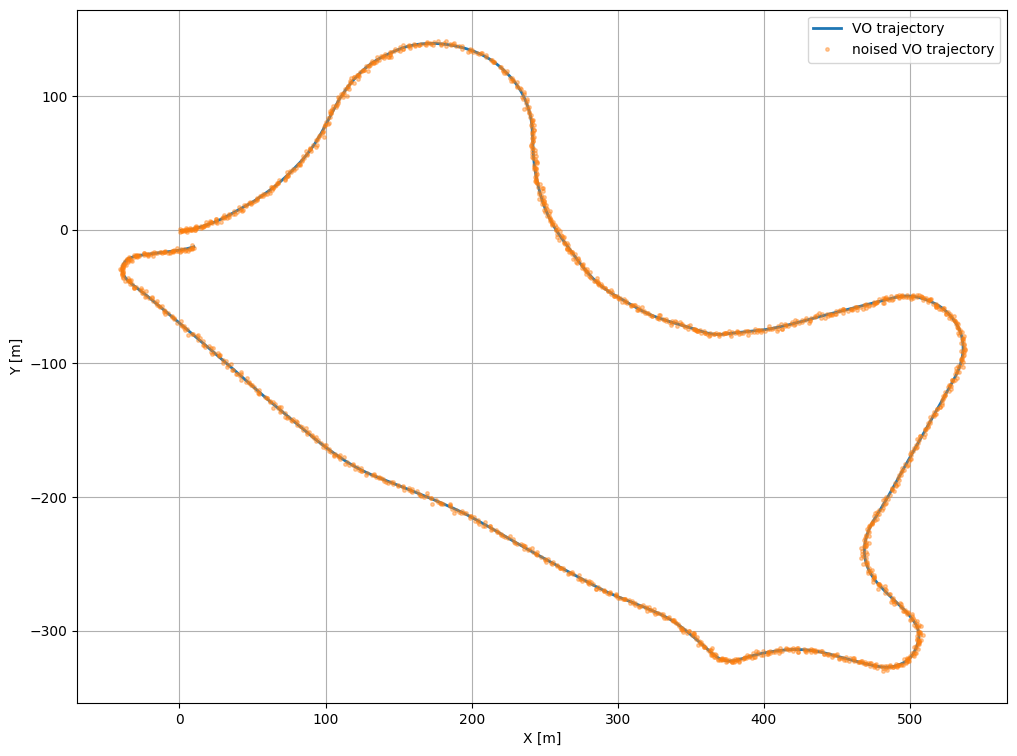

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

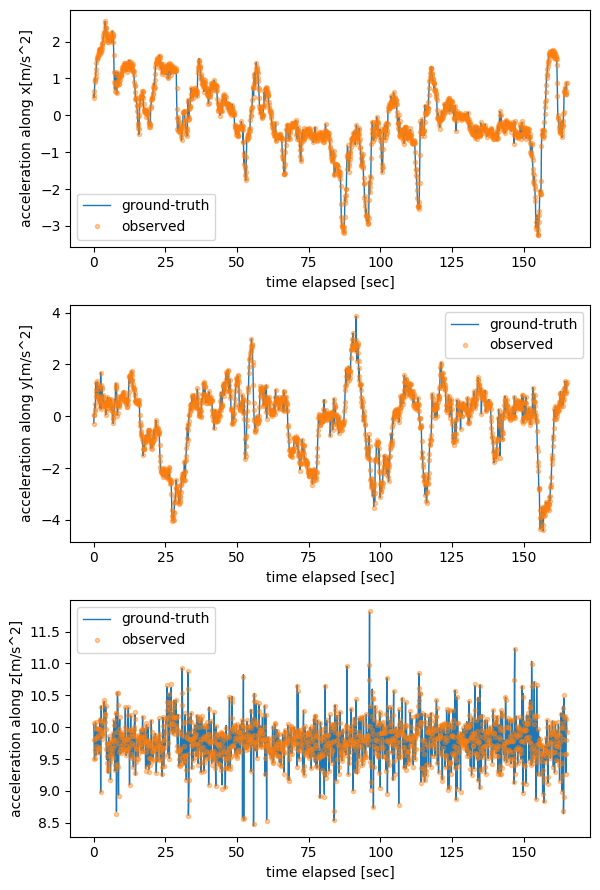

In [7]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

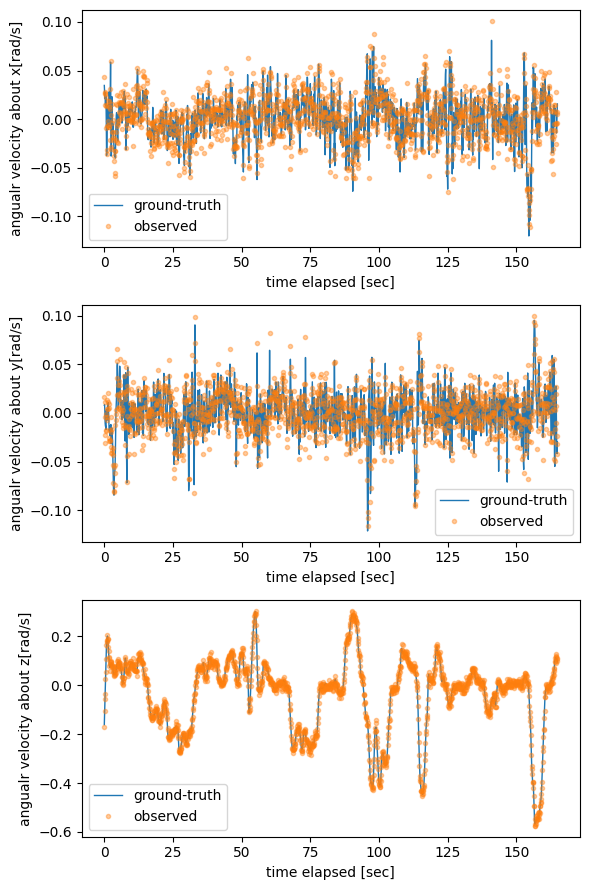

In [8]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

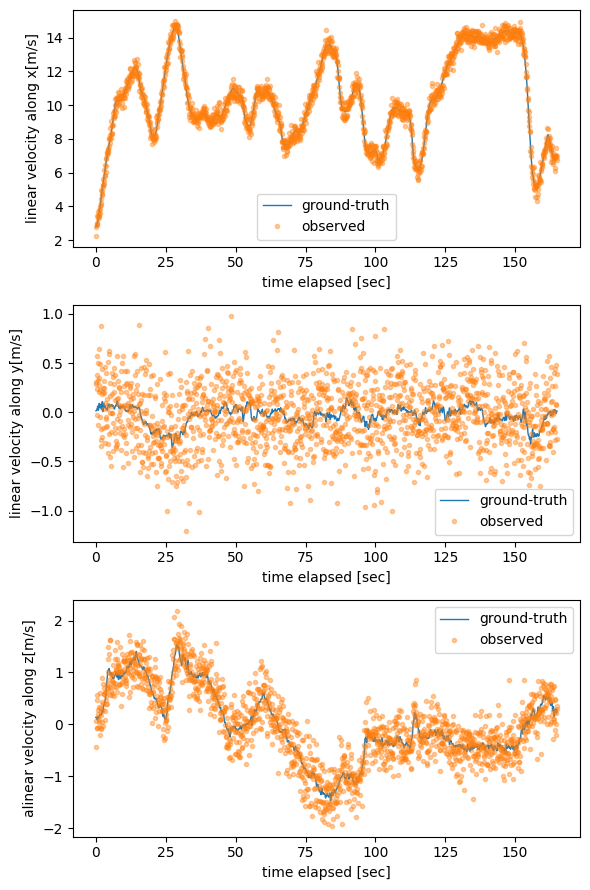

In [9]:
data.show_linear_velocity_with_noise()

# Filter Test

In [3]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 6.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 1.0
beta_setup2_0 = 6.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 4.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 512
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_0 = 512
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_0 = 256
resampling_algorithm_setup3_0 = ResamplingAlgorithms.RESIDUAL

n_ensemble_setup1_0 = 32
n_ensemble_setup2_0 = 512
n_ensemble_setup3_0 = 64

# Setup1 (IMU, VO)

## Extended Kalman Filter (EKF)

In [4]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EKF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4859.60it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 3.883, <ErrorEnum.RMSE: 2>: 5.523, <ErrorEnum.MAX: 3>: 16.49}


{<ErrorEnum.MAE: 1>: 3.883,
 <ErrorEnum.RMSE: 2>: 5.523,
 <ErrorEnum.MAX: 3>: 16.49}

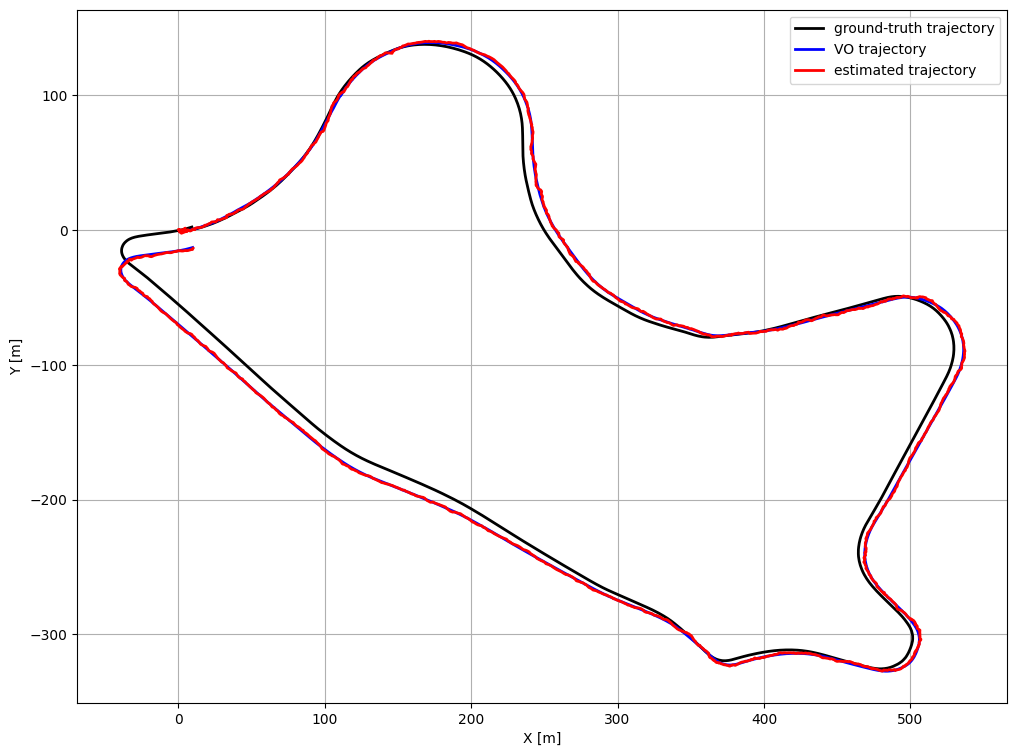

In [5]:
ekf1_0 = ExtendedKalmanFilter(x=x_setup1.copy(), 
                              P=P_setup1.copy(), 
                              H=H_setup1.copy(),
                              q=q1,
                              r_vo=r_vo1,
                              r_gps=r_gps1,
                              setup=SetupEnum.SETUP_1
                              )
ekf1_0.run(data=data, debug_mode=True, show_graph=True)

## Unscented Kalman Filter (UKF)

In [6]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.UKF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 3186.65it/s]

[UKF] errors: {<ErrorEnum.MAE: 1>: 3.9, <ErrorEnum.RMSE: 2>: 5.5, <ErrorEnum.MAX: 3>: 16.296}


{<ErrorEnum.MAE: 1>: 3.9, <ErrorEnum.RMSE: 2>: 5.5, <ErrorEnum.MAX: 3>: 16.296}

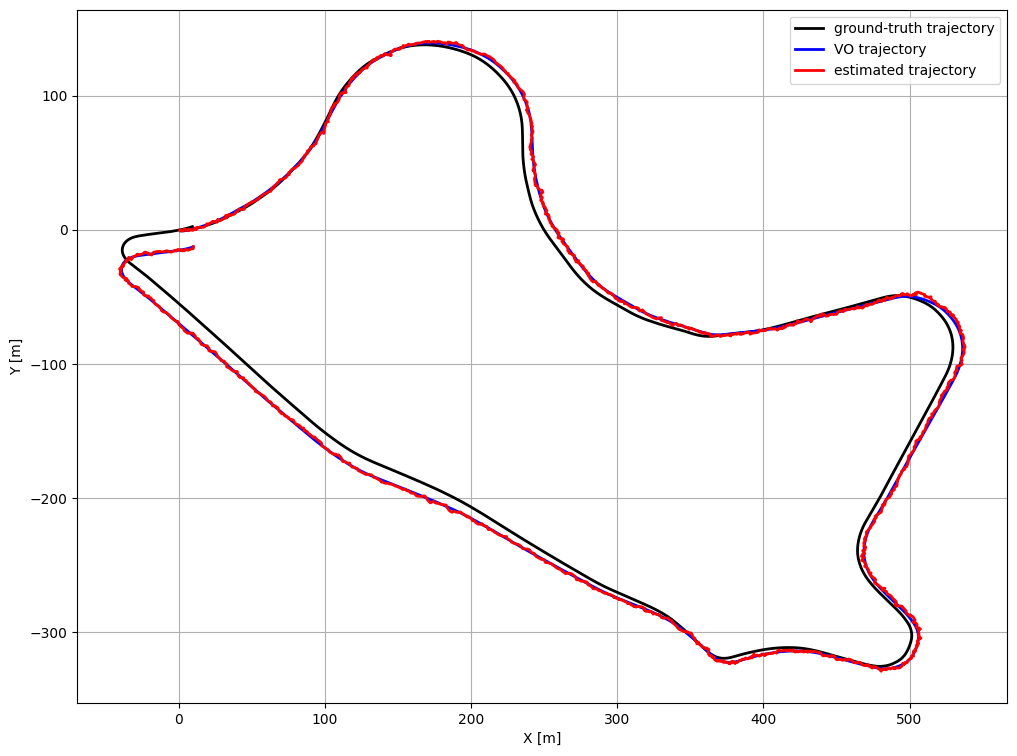

In [7]:
ukf1_0 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1
)
ukf1_0.run(data=data, debug_mode=True, show_graph=True)

## Particle Filter (PF)

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.PF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:58<00:00, 27.05it/s]

[PF] errors: {<ErrorEnum.MAE: 1>: 3.862, <ErrorEnum.RMSE: 2>: 5.474, <ErrorEnum.MAX: 3>: 16.272}


{<ErrorEnum.MAE: 1>: 3.862,
 <ErrorEnum.RMSE: 2>: 5.474,
 <ErrorEnum.MAX: 3>: 16.272}

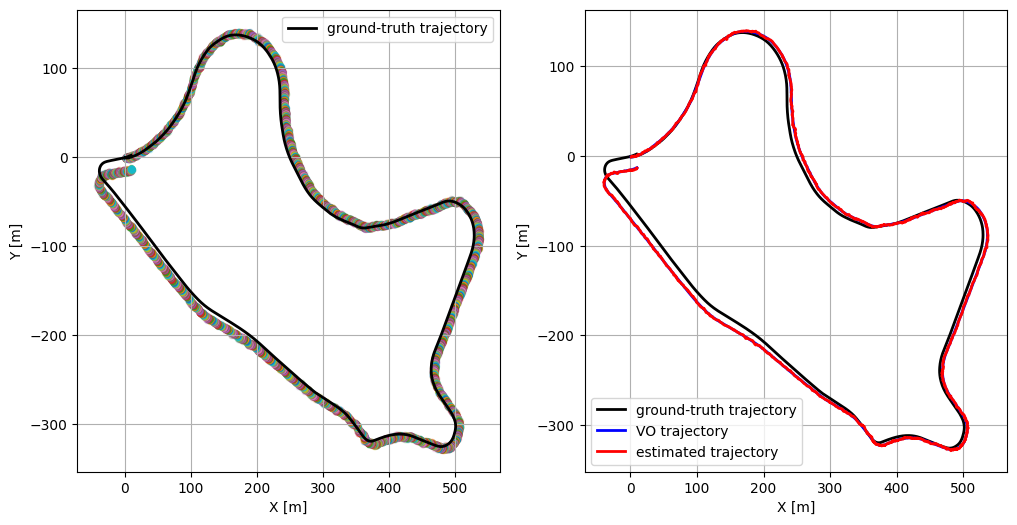

In [9]:
pf1_0 = ParticleFilter(N=2048, 
                        x_dim=x_setup1.shape[0], 
                        H=H_setup1.copy(), 
                        q=q1,
                        r_vo=r_vo1,
                        r_gps=r_gps1,
                        setup=SetupEnum.SETUP_1,
                        resampling_algorithm=resampling_algorithm_setup1_0)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf1_0.run(data=data, debug_mode=True, show_graph=True)

## Ensemble Kalman Filter (EnKF)

In [10]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EnKF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 542.44it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 4.096, <ErrorEnum.RMSE: 2>: 5.653, <ErrorEnum.MAX: 3>: 17.526}


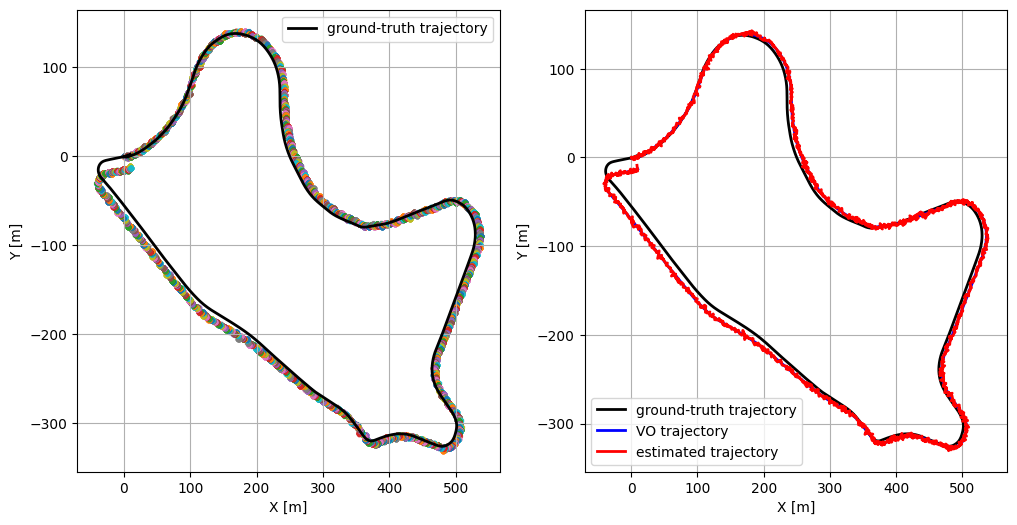

In [13]:
enkf1_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True, show_graph=True)

## Cubature Kalman Filter (CKF)

In [15]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.CKF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 3268.67it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 3.86, <ErrorEnum.RMSE: 2>: 5.427, <ErrorEnum.MAX: 3>: 16.714}


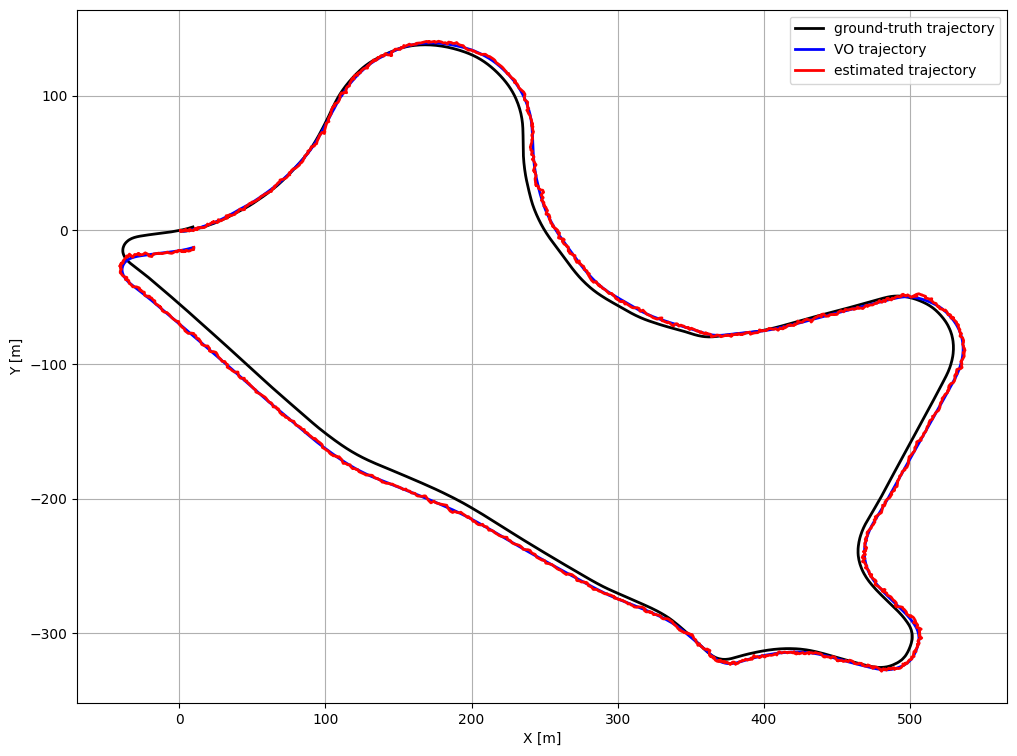

In [18]:
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True, show_graph=True)

# Setup2 (IMU, VO+GPS)

In [19]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

## EKF

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5648.19it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.982, <ErrorEnum.RMSE: 2>: 2.805, <ErrorEnum.MAX: 3>: 8.911}


{<ErrorEnum.MAE: 1>: 1.982,
 <ErrorEnum.RMSE: 2>: 2.805,
 <ErrorEnum.MAX: 3>: 8.911}

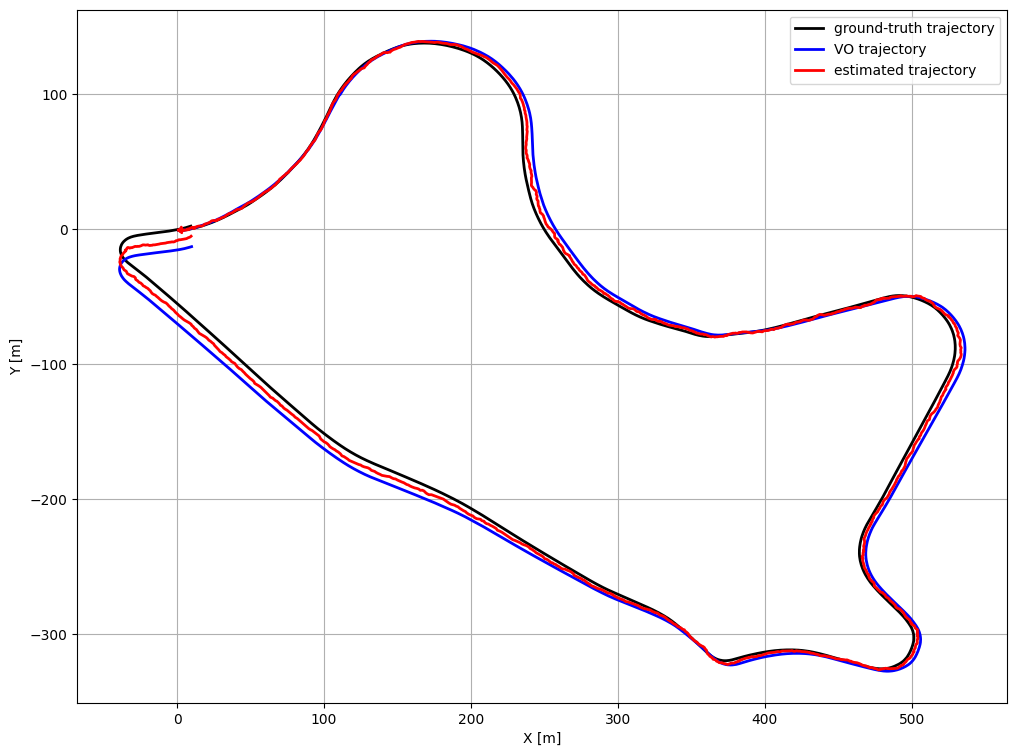

In [20]:
ekf2_0 = ExtendedKalmanFilter(x=x_setup2.copy(), 
                              P=P_setup2.copy(), 
                              H=H_setup2.copy(),
                              q=q2,
                              r_vo=r_vo2,
                              r_gps=r_gps2,
                              setup=SetupEnum.SETUP_2
                              )
ekf2_0.run(data=data, debug_mode=True, show_graph=True)

## UKF

In [21]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2253.46it/s]

[UKF] errors: {<ErrorEnum.MAE: 1>: 1.443, <ErrorEnum.RMSE: 2>: 1.932, <ErrorEnum.MAX: 3>: 6.274}


{<ErrorEnum.MAE: 1>: 1.443,
 <ErrorEnum.RMSE: 2>: 1.932,
 <ErrorEnum.MAX: 3>: 6.274}

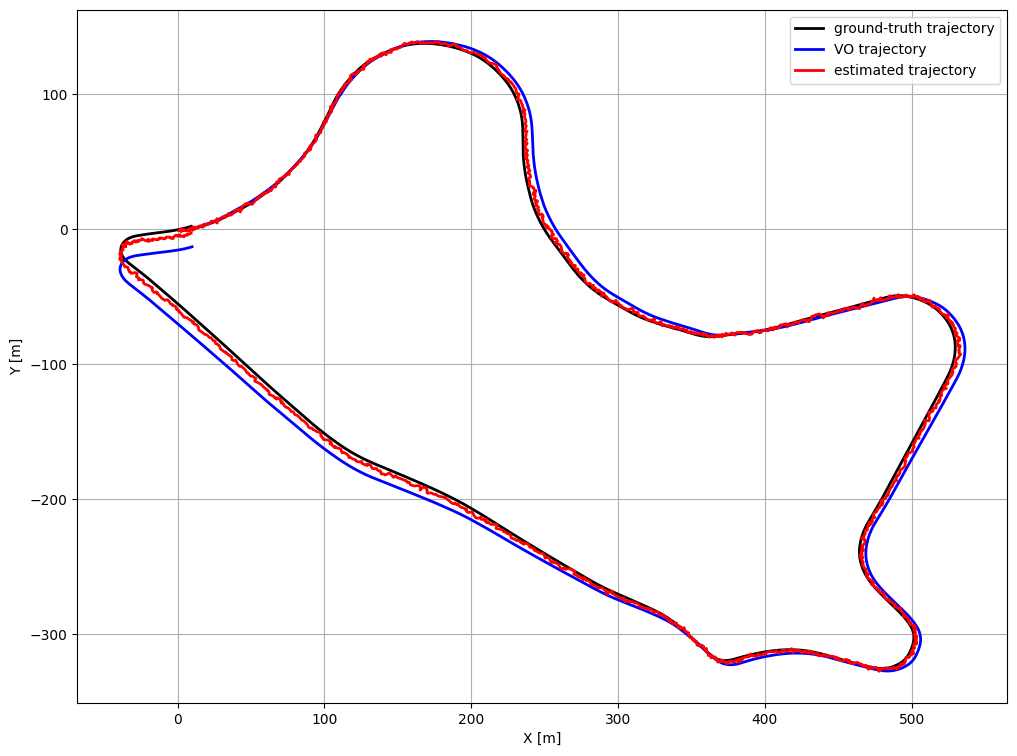

In [22]:
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2
)

ukf2_0.run(data=data, debug_mode=True, show_graph=True)

## PF

In [31]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:40<00:00, 15.79it/s]

[PF] errors: {<ErrorEnum.MAE: 1>: 0.448, <ErrorEnum.RMSE: 2>: 0.562, <ErrorEnum.MAX: 3>: 2.175}


{<ErrorEnum.MAE: 1>: 0.448,
 <ErrorEnum.RMSE: 2>: 0.562,
 <ErrorEnum.MAX: 3>: 2.175}

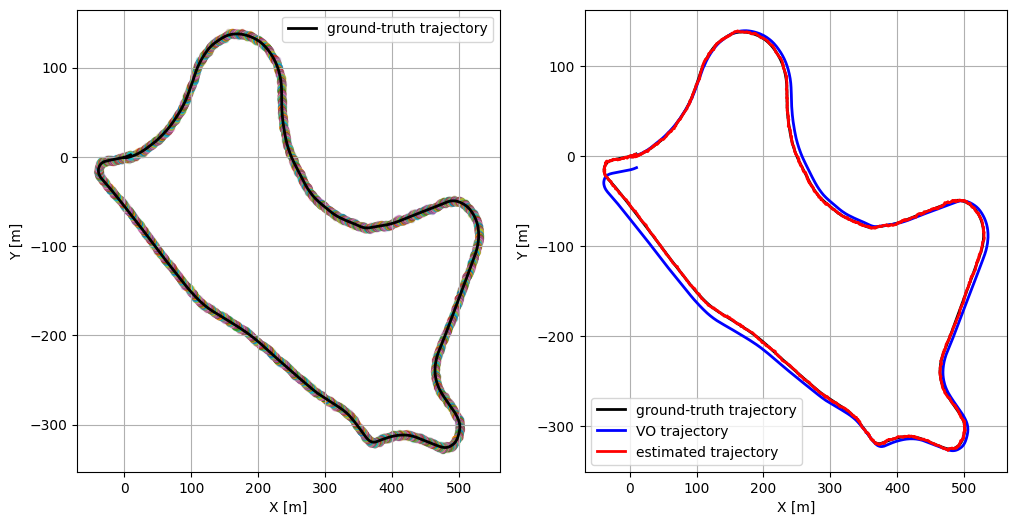

In [32]:
pf2_0 = ParticleFilter(N=2048, 
                        x_dim=x_setup2.shape[0], 
                        H=H_setup2.copy(), 
                        q=q2,
                        r_vo=r_vo2,
                        r_gps=r_gps2,
                        setup=SetupEnum.SETUP_2,
                        resampling_algorithm=resampling_algorithm_setup2_0)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf2_0.run(data=data, debug_mode=True, show_graph=True)

## EnKF

In [25]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:12<00:00, 125.88it/s]

[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.88, <ErrorEnum.RMSE: 2>: 2.482, <ErrorEnum.MAX: 3>: 11.741}


{<ErrorEnum.MAE: 1>: 1.88,
 <ErrorEnum.RMSE: 2>: 2.482,
 <ErrorEnum.MAX: 3>: 11.741}

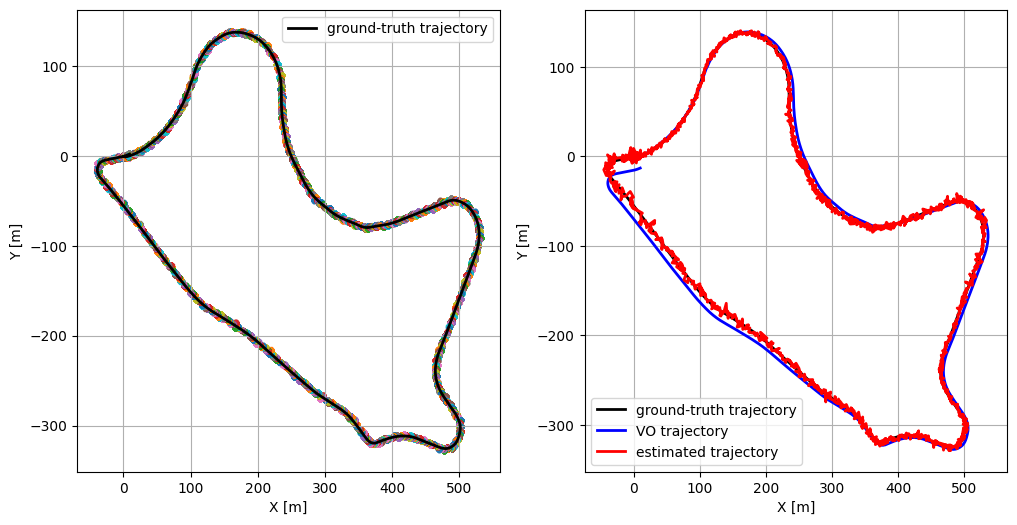

In [26]:
enkf2_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

enkf2_0.run(data=data, debug_mode=True, show_graph=True)

## Cubature Kalman Filter (CKF)

In [29]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2439.39it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.462, <ErrorEnum.RMSE: 2>: 1.975, <ErrorEnum.MAX: 3>: 6.469}


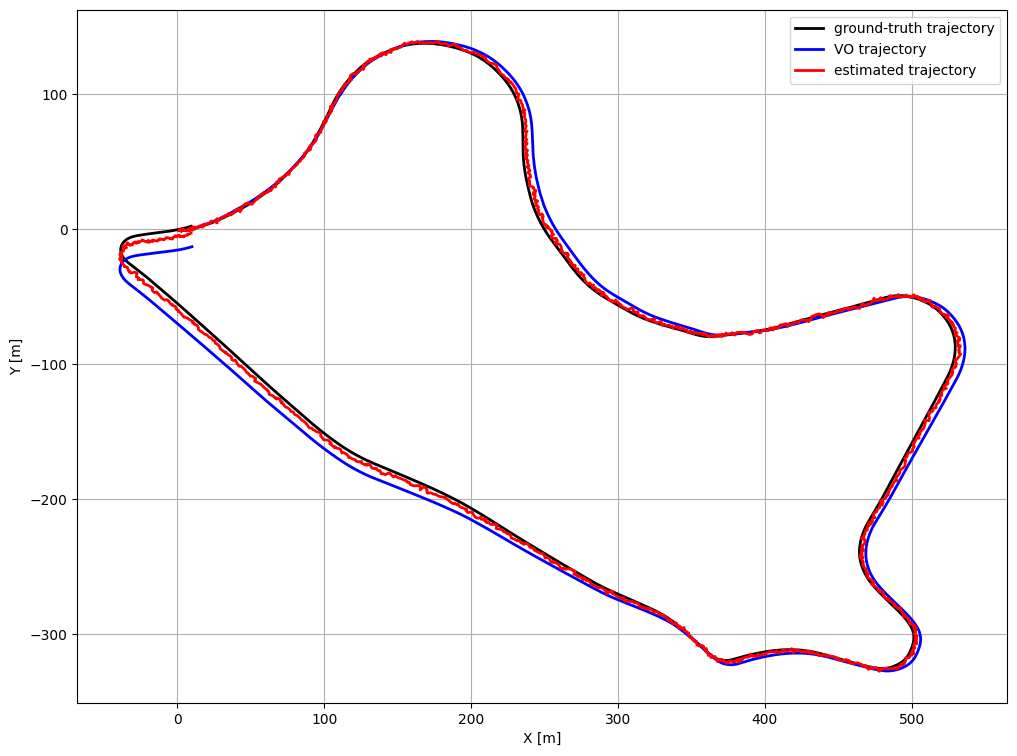

In [30]:
ckf2_0 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True, show_graph=True)

# Setup3 (INS)

In [33]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 14991.51it/s]

[EKF] errors: {<ErrorEnum.MAE: 1>: 1.942, <ErrorEnum.RMSE: 2>: 2.751, <ErrorEnum.MAX: 3>: 8.198}


{<ErrorEnum.MAE: 1>: 1.942,
 <ErrorEnum.RMSE: 2>: 2.751,
 <ErrorEnum.MAX: 3>: 8.198}

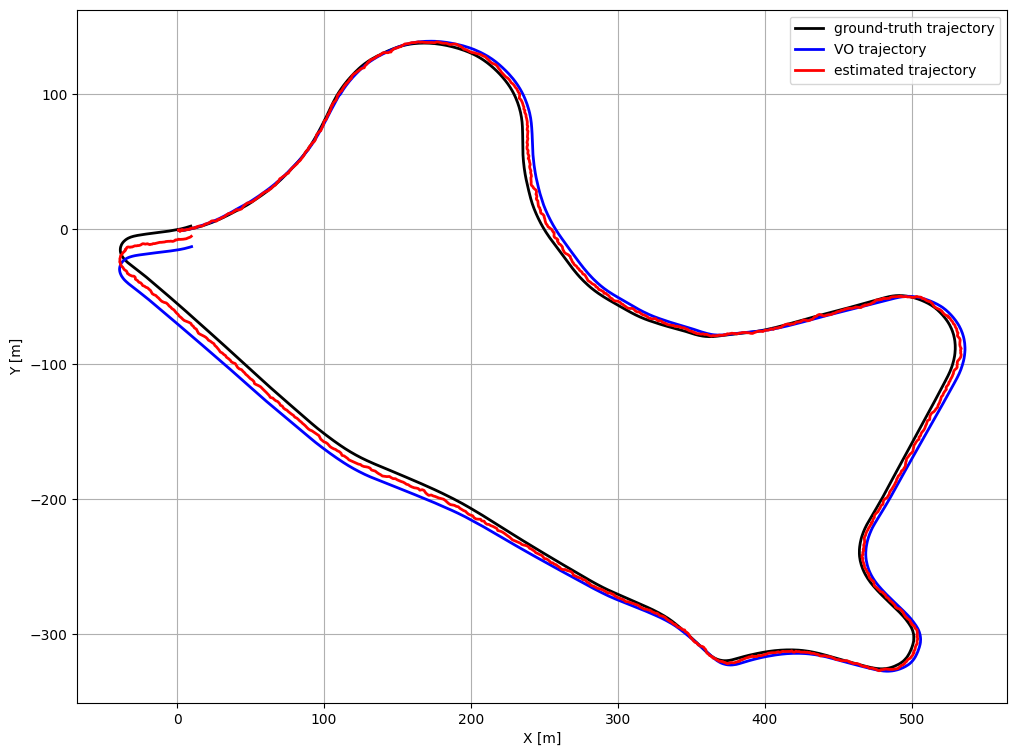

In [34]:
ekf3_0 = ExtendedKalmanFilter(x=x_setup3.copy(), 
                              P=P_setup3.copy(), 
                              H=H_setup3.copy(),
                              q=q3,
                              r_vo=r_vo3,
                              r_gps=r_gps3,
                              setup=SetupEnum.SETUP_3
                              )

ekf3_0.run(data=data, debug_mode=True, show_graph=True)

## UKF

In [35]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5305.73it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.565, <ErrorEnum.RMSE: 2>: 2.151, <ErrorEnum.MAX: 3>: 6.577}


{<ErrorEnum.MAE: 1>: 1.565,
 <ErrorEnum.RMSE: 2>: 2.151,
 <ErrorEnum.MAX: 3>: 6.577}

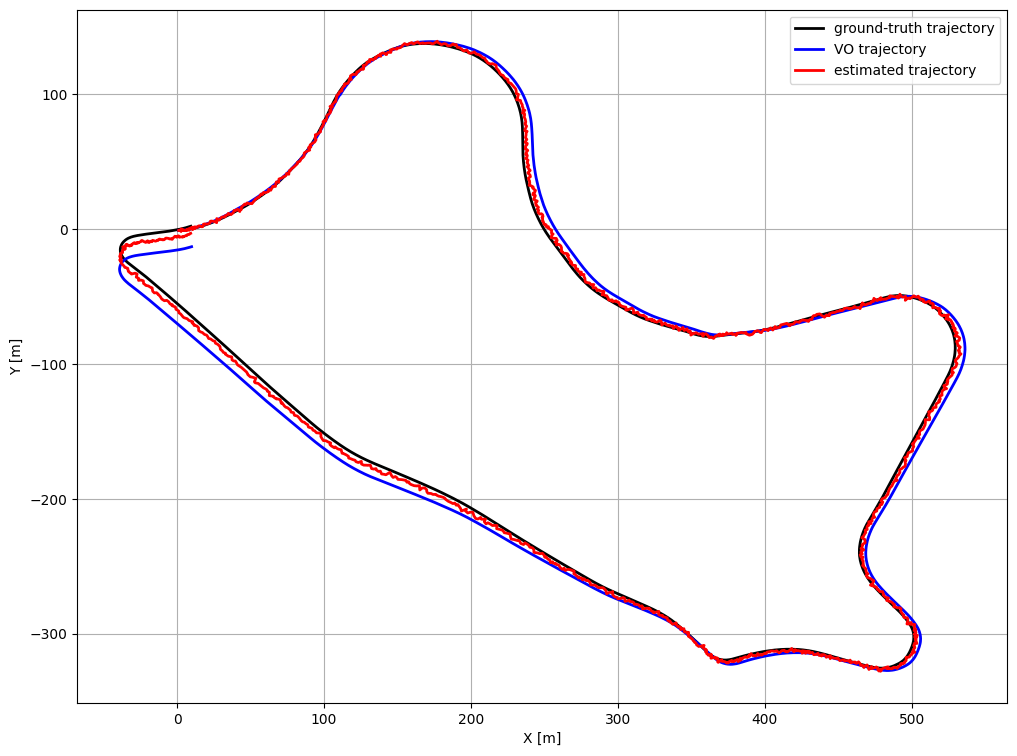

In [36]:
ukf3_0 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3
)

ukf3_0.run(data=data, debug_mode=True, show_graph=True)

## PF

In [37]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[PF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:13<00:00, 118.02it/s]

[PF] errors: {<ErrorEnum.MAE: 1>: 0.305, <ErrorEnum.RMSE: 2>: 0.388, <ErrorEnum.MAX: 3>: 1.671}


{<ErrorEnum.MAE: 1>: 0.305,
 <ErrorEnum.RMSE: 2>: 0.388,
 <ErrorEnum.MAX: 3>: 1.671}

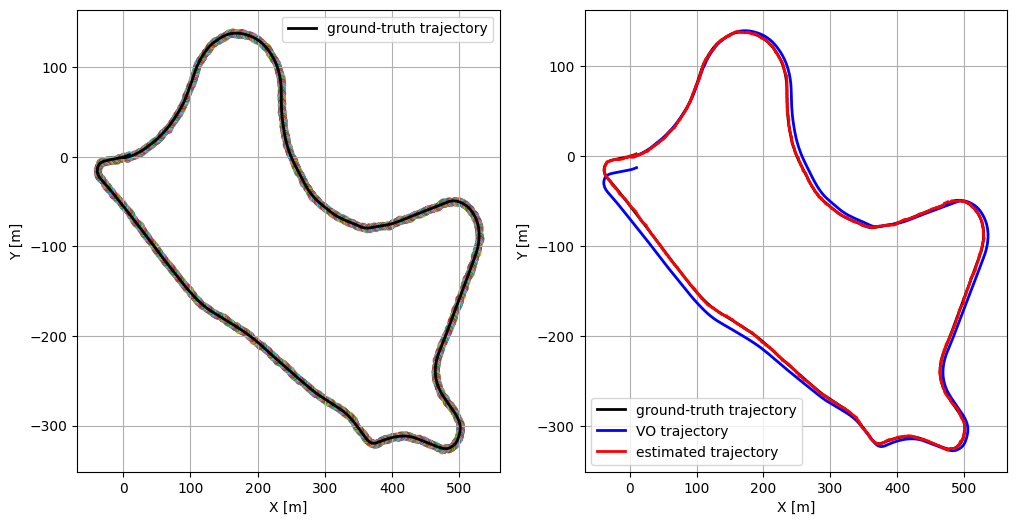

In [38]:
pf3_0 = ParticleFilter(N=n_samples_setup3_0, 
                        x_dim=x_setup3.shape[0], 
                        H=H_setup3.copy(), 
                        q=q3,
                        r_vo=r_vo3,
                        r_gps=r_gps3,
                        setup=SetupEnum.SETUP_3,
                        resampling_algorithm=resampling_algorithm_setup3_0)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

pf3_0.run(data=data, debug_mode=True, show_graph=True)

## EnKF

In [39]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 477.55it/s]

[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.095, <ErrorEnum.RMSE: 2>: 1.389, <ErrorEnum.MAX: 3>: 5.273}


{<ErrorEnum.MAE: 1>: 1.095,
 <ErrorEnum.RMSE: 2>: 1.389,
 <ErrorEnum.MAX: 3>: 5.273}

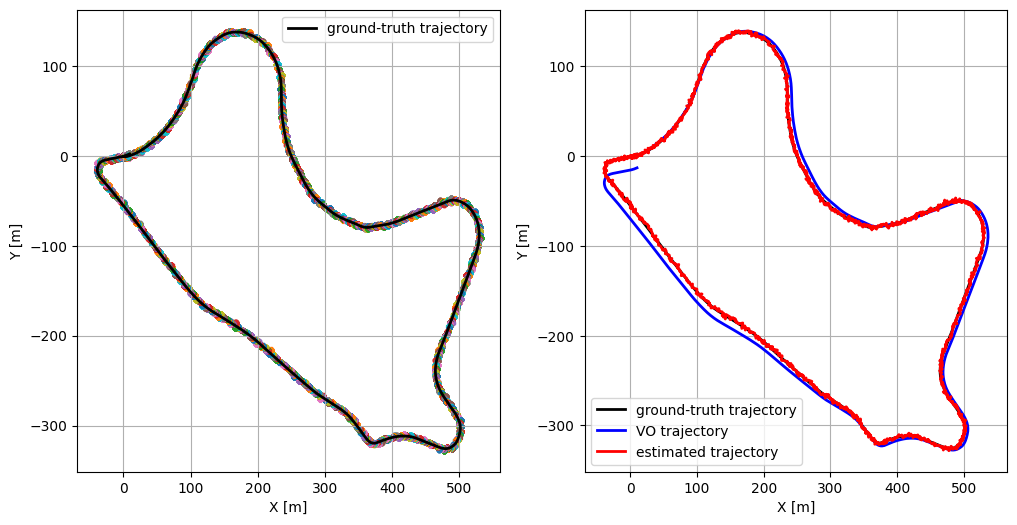

In [40]:
enkf3_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

enkf3_0.run(data=data, debug_mode=True, show_graph=True)

## Cubature Kalman Filter (CKF)

In [41]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6074.34it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.546, <ErrorEnum.RMSE: 2>: 2.108, <ErrorEnum.MAX: 3>: 6.591}


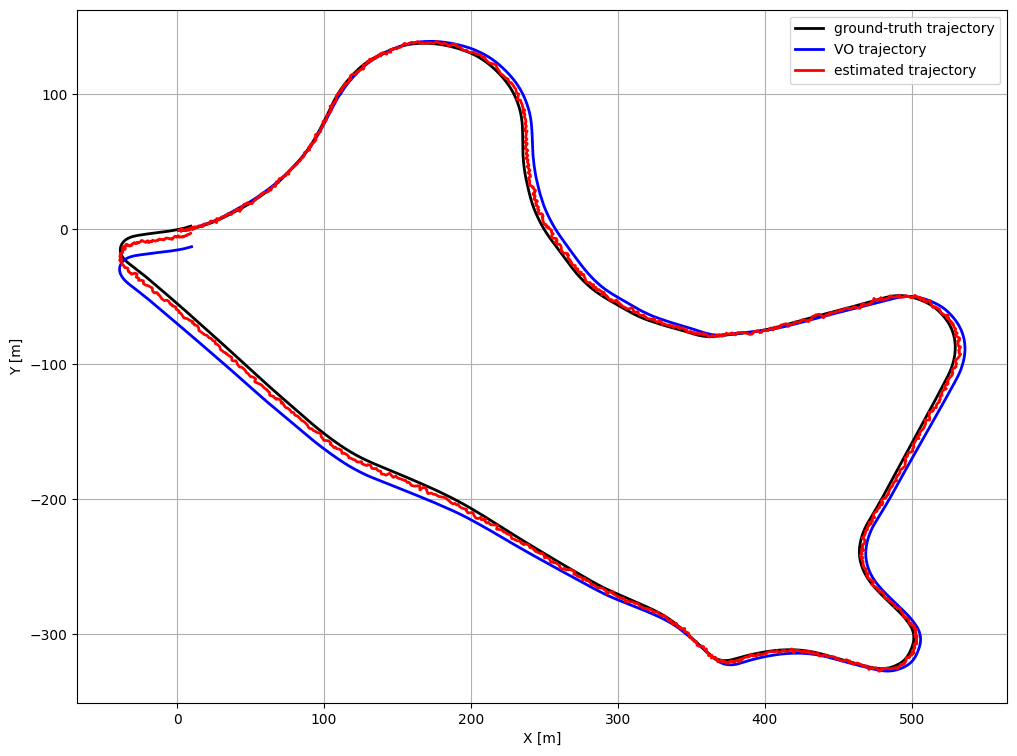

In [42]:
ckf3_0 = CubatureKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True, show_graph=True)